In [8]:
import copernicusmarine
import xarray as xr

In [2]:
ds_baltic = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_bal_phy_anfc_P1D-m",
    service="arco-geo-series",
)

ds_baltic

INFO - 2026-03-09T14:05:13Z - Selected dataset version: "202411"
INFO - 2026-03-09T14:05:13Z - Selected dataset part: "default"


<xarray.Dataset> Size: 806GB
Dimensions:    (depth: 56, latitude: 774, longitude: 763, time: 1197)
Coordinates:
  * depth      (depth) float32 224B 0.5016 1.516 2.548 ... 663.9 688.0 712.0
  * latitude   (latitude) float32 3kB 53.01 53.02 53.04 ... 65.86 65.87 65.89
  * longitude  (longitude) float32 3kB 9.042 9.069 9.097 ... 30.15 30.18 30.21
  * time       (time) datetime64[ns] 10kB 2022-12-02 2022-12-03 ... 2026-03-12
Data variables:
    bottomT    (time, latitude, longitude) float32 3GB dask.array<chunksize=(100, 774, 763), meta=np.ndarray>
    mlotst     (time, latitude, longitude) float32 3GB dask.array<chunksize=(100, 774, 763), meta=np.ndarray>
    siconc     (time, latitude, longitude) float32 3GB dask.array<chunksize=(100, 774, 763), meta=np.ndarray>
    sithick    (time, latitude, longitude) float32 3GB dask.array<chunksize=(100, 774, 763), meta=np.ndarray>
    so         (time, depth, latitude, longitude) float32 158GB dask.array<chunksize=(100, 2, 774, 763), meta=np.ndarray>
    sob        (time, latitude, longitude) float32 3GB dask.array<chunksize=(100, 774, 763), meta=np.ndarray>
    thetao     (time, depth, latitude, longitude) float32 158GB dask.array<chunksize=(100, 2, 774, 763), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float32 158GB dask.array<chunksize=(100, 2, 774, 763), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float32 158GB dask.array<chunksize=(100, 2, 774, 763), meta=np.ndarray>
    wo         (time, depth, latitude, longitude) float32 158GB dask.array<chunksize=(100, 2, 774, 763), meta=np.ndarray>
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:09
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-11-30 12:00:00
    stop_date:                 2024-11-30 12:00:00
    title:                     CMEMS NEMO daily integrated model fields
    westernmost_longitude:     9.041582107543945
    copernicusmarine_version:  2.3.0

In [7]:
_ds = ds_baltic.sel(
    time="2025-07-01", method="nearest"
).isel(
    depth=slice(0, 6)
)[["uo", "vo"]]
_ds.compute().drop_encoding().to_netcdf("ds_baltic.nc")

In [11]:
!du -sh ds_baltic.nc

 27M	ds_baltic.nc


In [12]:
ds_baltic = xr.open_dataset("ds_baltic.nc")
ds_baltic

<xarray.Dataset> Size: 28MB
Dimensions:    (depth: 6, latitude: 774, longitude: 763)
Coordinates:
  * depth      (depth) float32 24B 0.5016 1.516 2.548 3.602 4.684 5.8
  * latitude   (latitude) float32 3kB 53.01 53.02 53.04 ... 65.86 65.87 65.89
  * longitude  (longitude) float32 3kB 9.042 9.069 9.097 ... 30.15 30.18 30.21
    time       datetime64[ns] 8B ...
Data variables:
    uo         (depth, latitude, longitude) float32 14MB ...
    vo         (depth, latitude, longitude) float32 14MB ...
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:09
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-11-30 12:00:00
    stop_date:                 2024-11-30 12:00:00
    title:                     CMEMS NEMO daily integrated model fields
    westernmost_longitude:     9.041582107543945
    copernicusmarine_version:  2.3.0

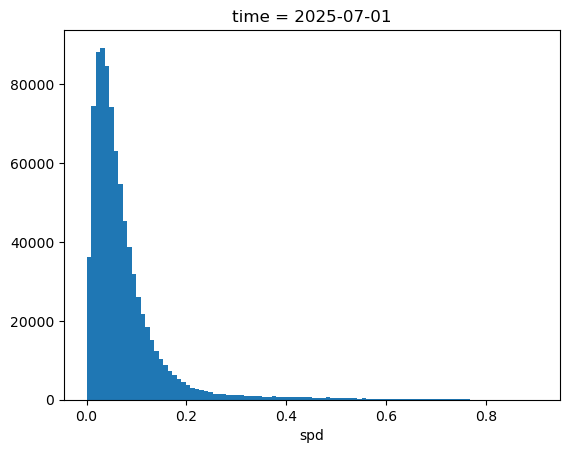

In [24]:
spd = (ds_baltic.to_array() ** 2).sum("variable") ** 0.5
spd = spd.where(spd > 0)
spd = spd.rename("spd")
spd.plot.hist(bins=100);

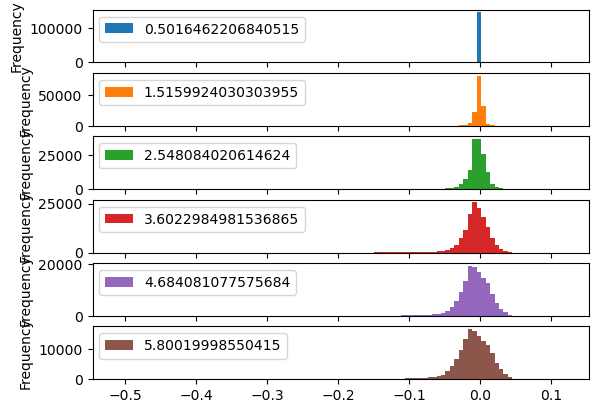

In [34]:
(spd - spd.isel(depth=0, drop=True)).to_dataframe().dropna()["spd"].unstack(0).plot.hist(subplots=True, bins=101);

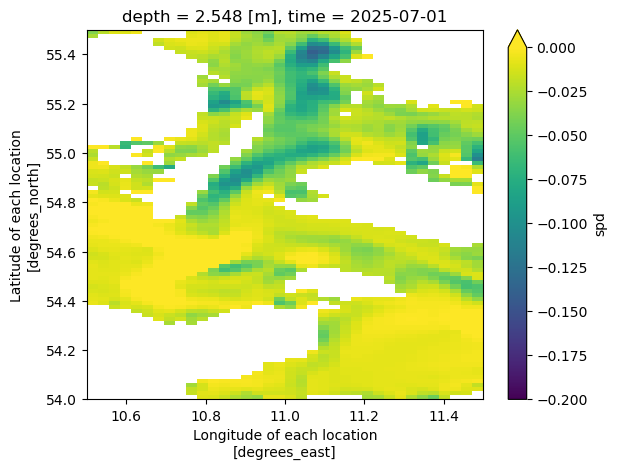

In [38]:
(spd.isel(depth=2) - spd.isel(depth=0, drop=True)).sel(
    longitude=slice(10.5, 11.5), latitude=slice(54, 55.5)
).plot(vmin=-0.2, vmax=0)

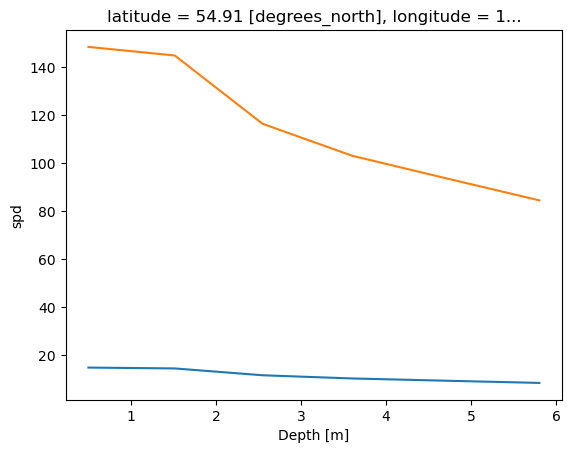

In [44]:
(20 * (spd.sel(longitude=10.9, latitude=54.9, method="nearest") ** 2)).plot()
(200 * (spd.sel(longitude=10.9, latitude=54.9, method="nearest") ** 2)).plot()

In [45]:
!pwd

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters
